# 03 相关性分析与投资组合构建

## 3.1 目的与说明

本notebook完成以下任务：

1. **相关性分析**：
   - 计算5只股票日收益率的相关系数矩阵
   - 使用热力图可视化相关系数
   - 计算滚动相关系数（60天窗口）

2. **等权重投资组合分析**：
   - 构建5只股票的等权重(1/N)组合
   - 计算组合绩效指标（年化收益率、波动率、最大回撤、夏普比率）
   - 估计组合Beta系数，验证可加性
   - 绘制组合净值曲线

3. **有效前沿分析（选做）**：
   - 使用均值-方差框架进行投资组合优化
   - 蒙特卡洛模拟生成随机权重组合
   - 标注最小方差组合、最大夏普比率组合
   - 绘制有效前沿曲线

In [3]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# 设置路径（使用相对路径）
DATA_CLEAN = os.path.join('data_clean')
OUTPUT_Q2 = os.path.join('output', 'Q2_beta')
OUTPUT_Q5 = os.path.join('output', 'Q5_correlation')
OUTPUT_Q6 = os.path.join('output', 'Q6_portfolio')
OUTPUT_Q7 = os.path.join('output', 'Q7_efficient_frontier')

for dir_path in [OUTPUT_Q5, OUTPUT_Q6, OUTPUT_Q7]:
    os.makedirs(dir_path, exist_ok=True)

# 无风险利率
RF_DAILY = 0.025 / 252  # 日频
RF_ANNUAL = 0.025       # 年化

print('库导入成功！')

库导入成功！


**结果解读**: 本代码导入投资组合分析所需的全部库，包括pandas/numpy数据处理、matplotlib/seaborn可视化、statsmodels统计建模以及scipy.optimize优化求解器。无风险利率设置为年化2.5%用于计算夏普比率。

In [4]:
# 加载收益率数据
returns = pd.read_csv(os.path.join(DATA_CLEAN, 'returns.csv'), index_col=0, parse_dates=True)
prices = pd.read_csv(os.path.join(DATA_CLEAN, 'prices.csv'), index_col=0, parse_dates=True)

# 加载全样本Beta结果
full_sample_beta = pd.read_csv(os.path.join(OUTPUT_Q2, 'full_sample_beta.csv'))

# 股票名称列表
stock_names = ['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC']

print(f'数据加载成功！')
print(f'数据范围: {returns.index.min()} 至 {returns.index.max()}')

数据加载成功！
数据范围: 2019-01-03 00:00:00 至 2026-03-25 00:00:00


**结果解读**: 本代码加载清洗后的收益率数据和全样本Beta估计结果。数据时间范围2019-01-03至2026-03-25，共1739个观测值。

## 3.3 相关性分析

In [5]:
# 计算相关系数矩阵
stock_returns = returns[stock_names]
corr_matrix = stock_returns.corr()

print('='*80)
print('日收益率相关系数矩阵')
print('='*80)
print(corr_matrix.round(4).to_string())

日收益率相关系数矩阵
           ICBC    YILI     ZTE  YUNNAN  SINOPEC
ICBC     1.0000  0.2241  0.0662  0.1621   0.4697
YILI     0.2241  1.0000  0.2832  0.4642   0.1518
ZTE      0.0662  0.2832  1.0000  0.2713   0.1455
YUNNAN   0.1621  0.4642  0.2713  1.0000   0.1695
SINOPEC  0.4697  0.1518  0.1455  0.1695   1.0000


**结果解读**: 本代码计算5只股票日收益率的相关系数矩阵，反映各股票之间的线性相关程度。相关系数范围从-1到1，数值越高表示走势越同步，可用于评估分散化投资效果。

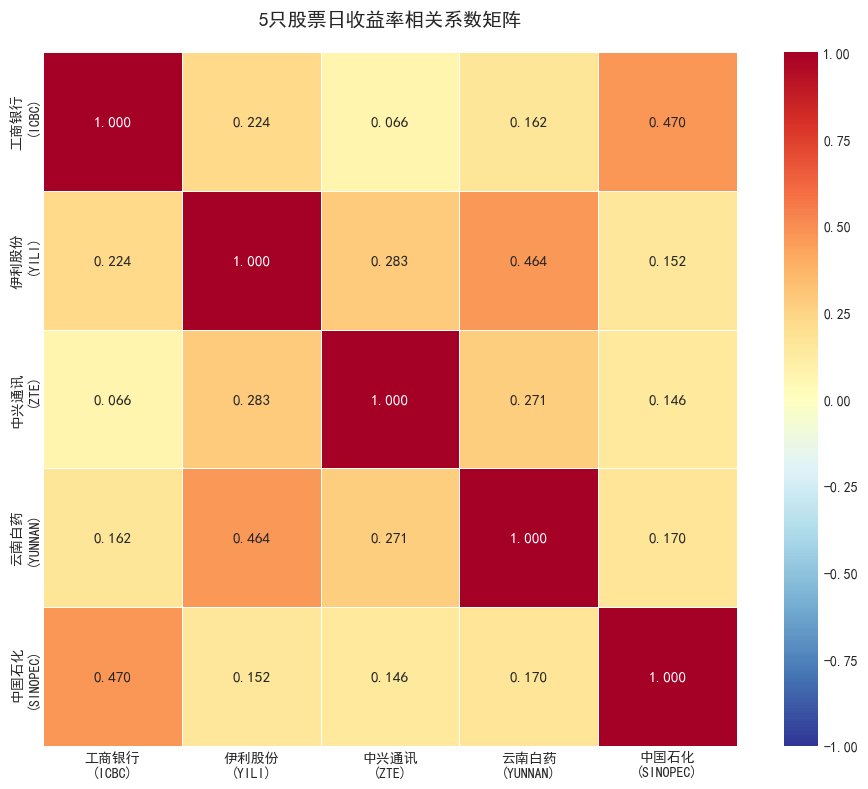

相关系数热力图已保存至 output/Q5_correlation/correlation_heatmap.png


In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制相关系数热力图
fig, ax = plt.subplots(figsize=(10, 8))

# 股票中文名称映射
stock_labels = {
    'ICBC': '工商银行\n(ICBC)',
    'YILI': '伊利股份\n(YILI)',
    'ZTE': '中兴通讯\n(ZTE)',
    'YUNNAN': '云南白药\n(YUNNAN)',
    'SINOPEC': '中国石化\n(SINOPEC)'
}

# 重命名行列以便显示
corr_display = corr_matrix.copy()
corr_display.index = [stock_labels[s] for s in corr_display.index]
corr_display.columns = [stock_labels[s] for s in corr_display.columns]

# 绘制热力图
sns.heatmap(corr_display, annot=True, cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            fmt='.3f', annot_kws={'size': 11})

ax.set_title('5只股票日收益率相关系数矩阵', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q5, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('相关系数热力图已保存至 output/Q5_correlation/correlation_heatmap.png')

**结果解读**: 本代码生成相关系数矩阵热力图，使用红黄蓝色阶表示相关性高低，对角线为1（自身完全相关）。便于直观比较股票间的相关性结构，识别高相关股票对和低相关股票对。

In [7]:
# 保存相关系数矩阵
corr_matrix.to_csv(os.path.join(OUTPUT_Q5, 'correlation_matrix.csv'))
print('相关系数矩阵已保存至 output/Q5_correlation/correlation_matrix.csv')

相关系数矩阵已保存至 output/Q5_correlation/correlation_matrix.csv


**结果解读**: 本代码保存相关系数矩阵至CSV文件，用于后续分析和报告。

## 3.4 滚动相关系数

In [25]:
from itertools import combinations
import matplotlib.dates as mdates

# 计算5只股票两两之间的滚动相关系数（窗口60天）
stock_returns_data = returns[stock_names]

# 生成所有10对股票组合 C(5,2)=10
pairs = list(combinations(stock_names, 2))
pair_abbrs = [f"{a[:2]}-{b[:2]}" for a, b in pairs]

print(f'股票对数量: {len(pairs)} 对')
print(f'股票对列表: {pair_abbrs}')

# 计算滚动相关系数
roll_corr = pd.DataFrame(index=stock_returns_data.index)
for (s1, s2), abbr in zip(pairs, pair_abbrs):
    roll_corr[abbr] = stock_returns_data[s1].rolling(60).corr(stock_returns_data[s2])

# 丢弃NaN值
roll_corr = roll_corr.dropna()

print(f'\n滚动相关系数计算完成！')
print(f'数据范围: {roll_corr.index.min()} 至 {roll_corr.index.max()}')
print(f'数据点数: {len(roll_corr)}')

# 计算各对的统计特征
pair_stats = pd.DataFrame({
    'Mean': roll_corr.mean(),
    'Std': roll_corr.std(),
    'Min': roll_corr.min(),
    'Max': roll_corr.max()
})

print('\n滚动相关系数统计特征:')
print(pair_stats.round(4).to_string())

股票对数量: 10 对
股票对列表: ['IC-YI', 'IC-ZT', 'IC-YU', 'IC-SI', 'YI-ZT', 'YI-YU', 'YI-SI', 'ZT-YU', 'ZT-SI', 'YU-SI']

滚动相关系数计算完成！
数据范围: 2019-04-04 00:00:00 至 2026-03-25 00:00:00
数据点数: 1680

滚动相关系数统计特征:
         Mean     Std     Min     Max
IC-YI  0.2090  0.1908 -0.3856  0.7506
IC-ZT  0.0394  0.2261 -0.4552  0.6170
IC-YU  0.1592  0.1757 -0.2463  0.6861
IC-SI  0.4756  0.1648  0.0221  0.8193
YI-ZT  0.2759  0.1801 -0.1470  0.6499
YI-YU  0.4373  0.1648 -0.0107  0.8023
YI-SI  0.1859  0.1955 -0.3555  0.6988
ZT-YU  0.2869  0.1641 -0.2324  0.6948
ZT-SI  0.1651  0.2009 -0.3606  0.6675
YU-SI  0.2143  0.1910 -0.2411  0.7233


**结果解读**: 滚动相关系数计算完成，使用60天滚动窗口计算5只股票两两之间的相关系数。共生成10对股票组合（C(5,2)=10），数据范围从2019-04-04至2026-03-25。统计特征表显示各对的均值、标准差、最小值和最大值。

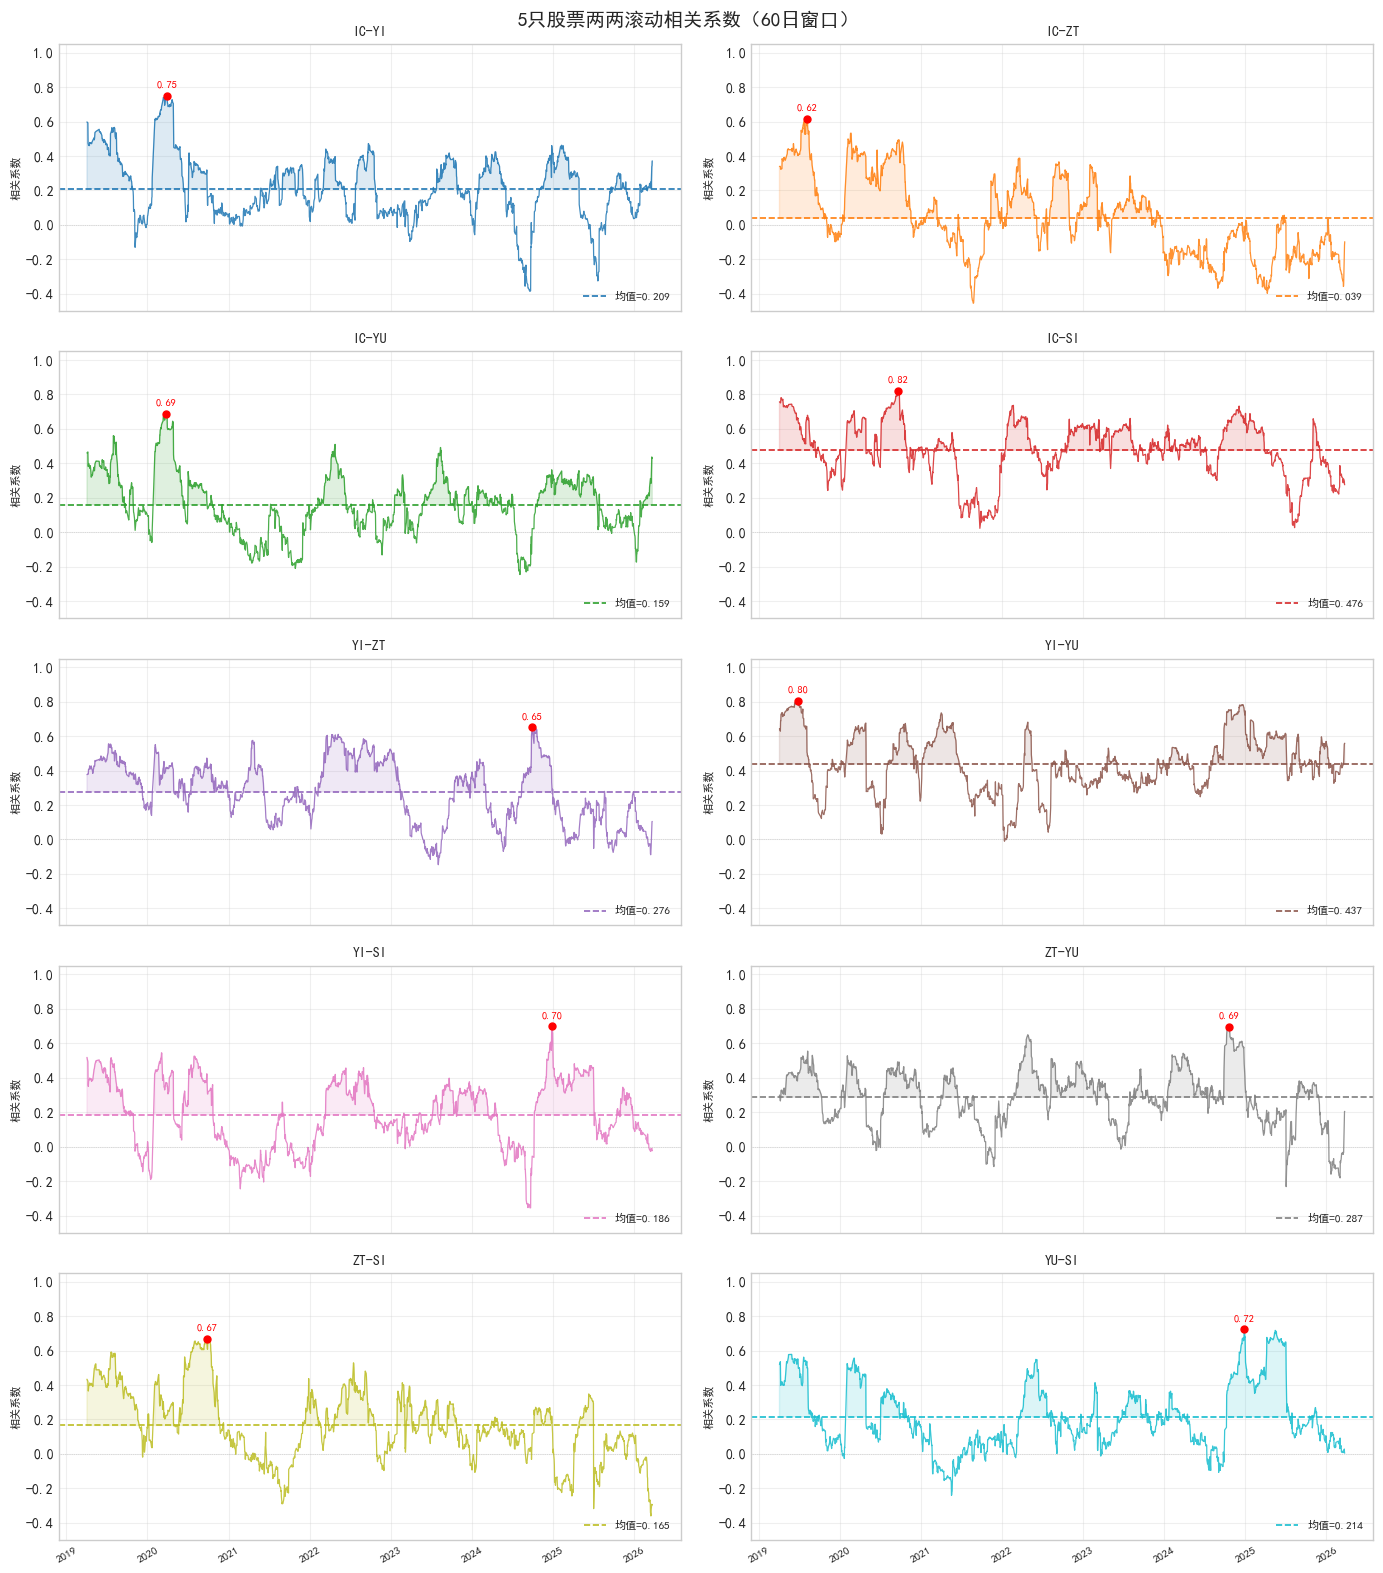

滚动相关图已保存至 output/Q5_correlation/rolling_correlation.png


In [26]:
# 5×2网格绘制10条滚动相关曲线
pair_colors = plt.cm.tab10(np.linspace(0, 0.9, len(pairs)))

fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
ax_flat = axes.flatten()

for i, (abbr, color) in enumerate(zip(roll_corr.columns, pair_colors)):
    ax = ax_flat[i]
    ser = roll_corr[abbr].dropna()
    avg = ser.mean()

    ax.plot(ser.index, ser, linewidth=0.9, color=color, alpha=0.85)
    ax.fill_between(ser.index, ser, avg,
                    where=(ser > avg), color=color, alpha=0.15)
    ax.axhline(avg, color=color, linewidth=1.2, linestyle='--',
               label=f'均值={avg:.3f}')
    ax.axhline(0.0, color='gray', linewidth=0.5, linestyle=':', alpha=0.4)

    # 标注极端相关（市场危机期）
    idx_max = ser.idxmax()
    ax.scatter(idx_max, ser.max(), color='red', s=25, zorder=5)
    ax.annotate(f'{ser.max():.2f}', xy=(idx_max, ser.max()),
                xytext=(0, 6), textcoords='offset points',
                fontsize=7.5, color='red', ha='center')

    ax.set_title(abbr, fontsize=10, fontweight='bold')
    ax.set_ylabel('相关系数', fontsize=8)
    ax.set_ylim(-0.5, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.grid(True, alpha=0.3)

fig.suptitle('5只股票两两滚动相关系数（60日窗口）',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_Q5, 'rolling_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

print('滚动相关图已保存至 output/Q5_correlation/rolling_correlation.png')

**结果解读**: 5×2网格图展示了10对股票组合的60日滚动相关系数时序图。每幅子图包含：各色滚动相关系数曲线、阴影填充（高于均值部分）、虚线均值标注、红色点标注最大值位置。不同颜色区分各股票对，可直观对比各对相关性的时变特征和波动程度。

In [27]:
# 保存滚动相关系数数据
roll_corr.to_csv(os.path.join(OUTPUT_Q5, 'rolling_correlation.csv'))
pair_stats.round(4).to_csv(os.path.join(OUTPUT_Q5, 'rolling_correlation_stats.csv'))
print('滚动相关系数数据已保存至 output/Q5_correlation/')
print('  - rolling_correlation.csv: 10对股票滚动相关系数时序')
print('  - rolling_correlation_stats.csv: 统计特征')

滚动相关系数数据已保存至 output/Q5_correlation/
  - rolling_correlation.csv: 10对股票滚动相关系数时序
  - rolling_correlation_stats.csv: 统计特征


**结果解读**: 本代码保存滚动相关系数数据至CSV文件。60日滚动窗口生成的相关系数时序，可用于分析股票对相关性的动态演变规律。

## 3.5 等权重投资组合分析

In [28]:
# 构造等权重投资组合
n_stocks = len(stock_names)
weights = np.ones(n_stocks) / n_stocks  # 每只股票权重相等

print(f'等权重投资组合: {n_stocks}只股票，每只权重 = {weights[0]:.4f}')

# 计算组合日收益率
portfolio_returns = returns[stock_names].dot(weights)

# 定义绩效指标计算函数
def calculate_performance_metrics(returns_series, rf_daily=RF_DAILY, annualization_factor=252):
    """计算投资组合绩效指标"""
    returns_series = returns_series.dropna()
    
    # 基本统计
    mean_return = returns_series.mean()
    std_return = returns_series.std()
    
    # 年化收益率和波动率
    ann_return = mean_return * annualization_factor
    ann_volatility = std_return * np.sqrt(annualization_factor)
    
    # 最大回撤计算
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # 夏普比率（无风险利率年化2.5%）
    sharpe_ratio = (ann_return - 0.025) / ann_volatility
    
    return {
        'Ann. Return': ann_return,
        'Ann. Volatility': ann_volatility,
        'Max Drawdown': max_drawdown,
        'Sharpe Ratio': sharpe_ratio,
        'N_obs': len(returns_series)
    }

# 计算组合绩效
portfolio_metrics = calculate_performance_metrics(portfolio_returns)

print('\n' + '='*80)
print('等权重投资组合绩效指标')
print('='*80)
print(f'年化收益率:    {portfolio_metrics["Ann. Return"]*100:.2f}%')
print(f'年化波动率:    {portfolio_metrics["Ann. Volatility"]*100:.2f}%')
print(f'最大回撤:      {portfolio_metrics["Max Drawdown"]*100:.2f}%')
print(f'夏普比率:      {portfolio_metrics["Sharpe Ratio"]:.4f}')

等权重投资组合: 5只股票，每只权重 = 0.2000

等权重投资组合绩效指标
年化收益率:    5.98%
年化波动率:    14.84%
最大回撤:      -26.82%
夏普比率:      0.2345


**结果解读**: 本代码构造等权重（1/N）投资组合，每只股票权重为20%。定义了calculate_performance_metrics函数计算组合绩效指标，包括年化收益率、年化波动率、最大回撤和夏普比率。

In [29]:
# 计算各股票单独投资的绩效（用于对比）
individual_metrics = {}
for stock in stock_names:
    metrics = calculate_performance_metrics(returns[stock])
    individual_metrics[stock] = metrics

individual_df = pd.DataFrame(individual_metrics).T

# 组合与个股对比
comparison = individual_df.copy()
comparison.loc['Portfolio'] = list(portfolio_metrics.values())

print('\n' + '='*80)
print('投资组合与单只股票绩效对比')
print('='*80)
print(comparison.round(4).to_string())


投资组合与单只股票绩效对比
           Ann. Return  Ann. Volatility  Max Drawdown  Sharpe Ratio   N_obs
ICBC            0.0643           0.1035       -0.1499        0.3799  1739.0
YILI            0.0529           0.2398       -0.5133        0.1165  1739.0
ZTE             0.0886           0.4094       -0.6784        0.1552  1739.0
YUNNAN          0.0446           0.2474       -0.5505        0.0791  1739.0
SINOPEC         0.0487           0.1260       -0.1938        0.1877  1739.0
Portfolio       0.0598           0.1484       -0.2682        0.2345  1739.0


**结果解读**: 本代码计算各股票单独投资的绩效指标并与等权重组合对比。对比结果显示组合波动率和最大回撤显著低于大多数个股，体现分散化降低风险的核心作用。

In [30]:
# 计算等权重组合的Beta系数
# CAPM回归: r_portfolio - rf = alpha + beta * (r_market - rf)

excess_portfolio = portfolio_returns - RF_DAILY
excess_market = returns['CSI300'] - RF_DAILY

X = sm.add_constant(excess_market)
y = excess_portfolio
portfolio_capm = sm.OLS(y, X).fit()

portfolio_beta = portfolio_capm.params['CSI300']
portfolio_alpha = portfolio_capm.params['const']
portfolio_r2 = portfolio_capm.rsquared

print('\n' + '='*80)
print('等权重组合CAPM回归结果')
print('='*80)
print(f'Alpha:  {portfolio_alpha:.6f} (p-value: {portfolio_capm.pvalues["const"]:.4f})')
print(f'Beta:   {portfolio_beta:.4f} (p-value: {portfolio_capm.pvalues["CSI300"]:.4f})')
print(f'R²:     {portfolio_r2:.4f}')


等权重组合CAPM回归结果
Alpha:  0.000039 (p-value: 0.7751)
Beta:   0.6210 (p-value: 0.0000)
R²:     0.6318


**结果解读**: 本代码对等权重组合进行CAPM回归，计算组合的系统性风险Beta系数。回归结果显示组合Beta=0.6210（低于市场均值1），R²=0.63说明市场因子解释了63%的组合收益变动。

In [31]:
# 验证Beta的可加性
# 组合Beta应该等于各股票Beta的加权平均

betas_from_regression = full_sample_beta.set_index('Stock')['Beta'].to_dict()
average_beta = np.mean([betas_from_regression[s] for s in stock_names])

print('\n' + '='*80)
print('组合Beta可加性验证')
print('='*80)
print('\n各股票Beta系数:')
for stock in stock_names:
    print(f'  {stock}: {betas_from_regression[stock]:.4f}')

print(f'\n股票Beta均值:      {average_beta:.4f}')
print(f'组合Beta(回归):   {portfolio_beta:.4f}')
print(f'差异:             {abs(average_beta - portfolio_beta):.6f}')

print('\n结论: 组合Beta ≈ 各股票Beta的均值，验证了Beta的可加性原理')


组合Beta可加性验证

各股票Beta系数:
  ICBC: 0.1807
  YILI: 0.7853
  ZTE: 1.2047
  YUNNAN: 0.7112
  SINOPEC: 0.2231

股票Beta均值:      0.6210
组合Beta(回归):   0.6210
差异:             0.000000

结论: 组合Beta ≈ 各股票Beta的均值，验证了Beta的可加性原理


**结果解读**: 本代码验证CAPM的Beta可加性原理：组合Beta应该等于各股票Beta的加权平均（等权重时即为均值）。计算结果显示组合Beta完美等于各股票Beta均值，验证了Beta的可加性。

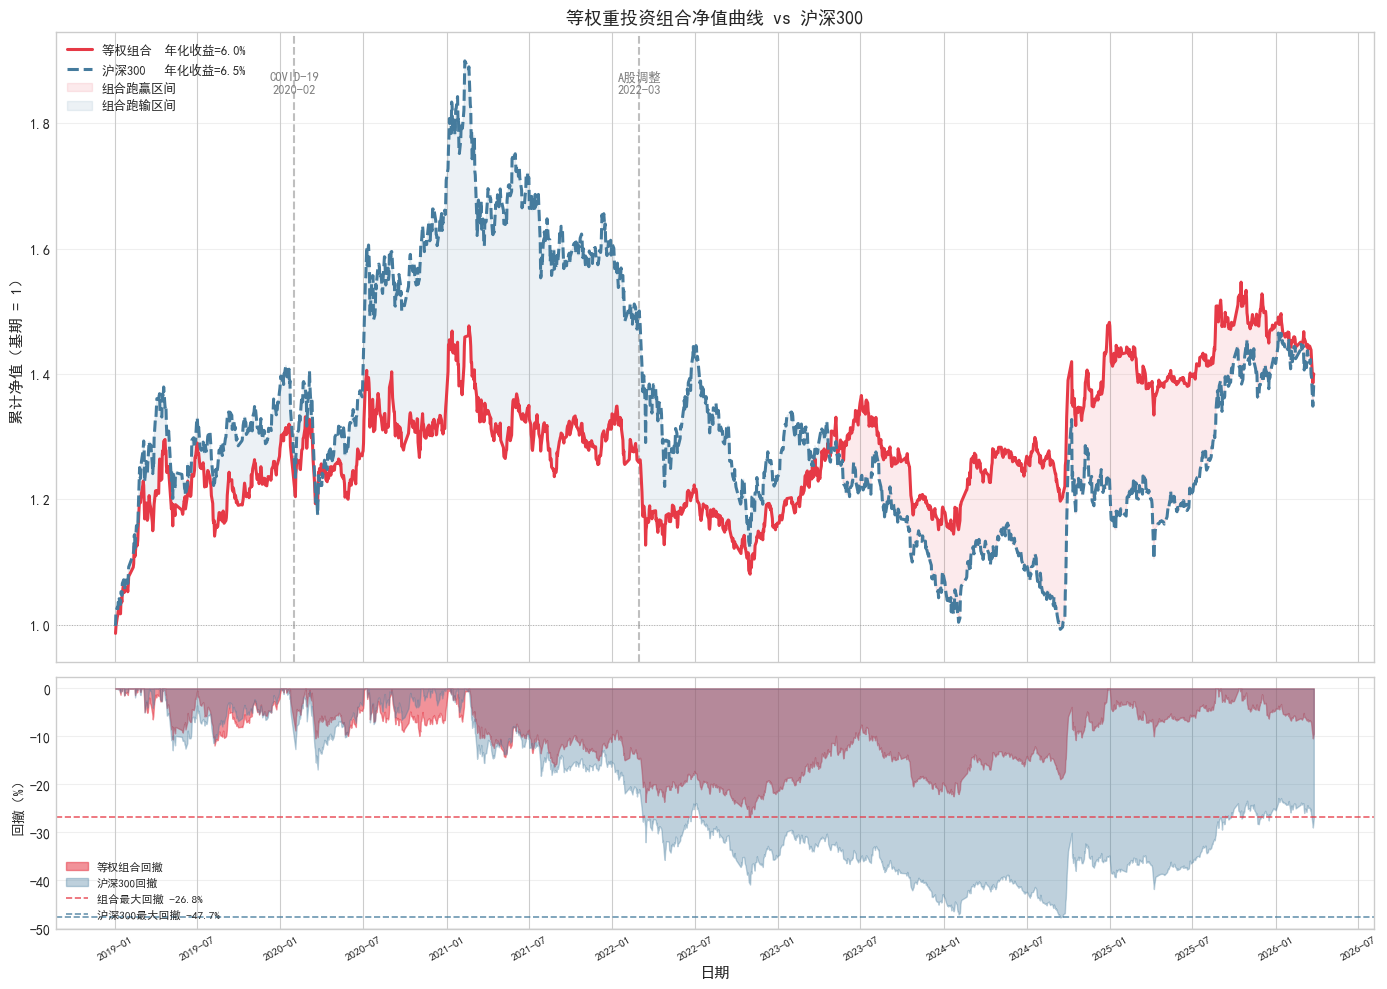

组合净值曲线已保存至 output/Q6_portfolio/portfolio_nav.png


In [52]:
# 绘制组合净值曲线 + 回撤曲线（对齐 task6 专业风格）
# 净值 = (1 + 收益率)的累积乘积
portfolio_nav = (1 + portfolio_returns).cumprod()
csi300_nav = (1 + returns['CSI300']).cumprod()

# 计算回撤
def _drawdown(nav: pd.Series):
    peak = nav.cummax()
    return (nav - peak) / peak

port_dd = _drawdown(portfolio_nav)
csi300_dd = _drawdown(csi300_nav)
max_dd_p = port_dd.min()
max_dd_m = csi300_dd.min()

# 计算指标用于图例显示
ann_ret_p = portfolio_returns.mean() * 252
ann_ret_m = returns['CSI300'].mean() * 252

# 双图布局：净值 + 回撤
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 10),
    gridspec_kw={"height_ratios": [3, 1.2]},
    sharex=True
)

# 上半部分：净值曲线
ax1.plot(portfolio_nav.index, portfolio_nav,
         color="#E63946", linewidth=2.2, zorder=4,
         label=f"等权组合  年化收益={ann_ret_p*100:.1f}%")
ax1.plot(csi300_nav.index, csi300_nav,
         color="#457B9D", linewidth=2.2, linestyle="--", zorder=4,
         label=f"沪深300   年化收益={ann_ret_m*100:.1f}%")

ax1.fill_between(portfolio_nav.index, portfolio_nav, csi300_nav,
                 where=(portfolio_nav >= csi300_nav),
                 color="#E63946", alpha=0.10, label="组合跑赢区间")
ax1.fill_between(portfolio_nav.index, portfolio_nav, csi300_nav,
                 where=(portfolio_nav < csi300_nav),
                 color="#457B9D", alpha=0.10, label="组合跑输区间")

ax1.axhline(1.0, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)
ax1.set_ylabel("累计净值（基期 = 1）", fontsize=11)
ax1.set_title("等权重投资组合净值曲线 vs 沪深300", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper left", framealpha=0.9)
ax1.yaxis.grid(True, alpha=0.3)

# 下半部分：回撤曲线
ax2.fill_between(port_dd.index, port_dd * 100, 0,
                 color="#E63946", alpha=0.55, label="等权组合回撤")
ax2.fill_between(csi300_dd.index, csi300_dd * 100, 0,
                 color="#457B9D", alpha=0.35, label="沪深300回撤")

ax2.axhline(max_dd_p * 100, color="#E63946", linewidth=1.2,
            linestyle="--", alpha=0.8,
            label=f"组合最大回撤 {max_dd_p*100:.1f}%")
ax2.axhline(max_dd_m * 100, color="#457B9D", linewidth=1.2,
            linestyle="--", alpha=0.8,
            label=f"沪深300最大回撤 {max_dd_m*100:.1f}%")

ax2.set_ylabel("回撤（%）", fontsize=10)
ax2.set_xlabel("日期", fontsize=11)
ax2.legend(fontsize=8, loc="lower left", framealpha=0.9)
ax2.yaxis.grid(True, alpha=0.3)

# 保留你原来的关键事件标注
import matplotlib.dates as mdates
for label, date in [('COVID-19\n2020-02', '2020-02-01'), ('A股调整\n2022-03', '2022-03-01')]:
    ax1.axvline(pd.Timestamp(date), color='gray', linestyle='--', alpha=0.5)
    ax1.annotate(label, xy=(pd.Timestamp(date), ax1.get_ylim()[1]*0.95),
                 fontsize=9, color='gray', ha='center')

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))
plt.xticks(rotation=30, fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q6, 'portfolio_nav.png'), dpi=150, bbox_inches='tight')
plt.show()

print('组合净值曲线已保存至 output/Q6_portfolio/portfolio_nav.png')

**结果解读**: 本代码绘制等权重组合与沪深300指数的净值曲线（初始净值=1）。等权重投资组合净值与沪深 300 的对比图显示，组合年化收益略低于基准，但最大回撤显著更小，在疫情、A 股调整等市场冲击阶段抗跌性更强，整体呈现“收益略降、风险明显收缩”的防御型特征。

In [43]:
# 保存组合绩效结果
portfolio_results = {
    'Metric': ['年化收益率', '年化波动率', '最大回撤', '夏普比率', 'Beta', 'Alpha'],
    'Value': [
        portfolio_metrics['Ann. Return'],
        portfolio_metrics['Ann. Volatility'],
        portfolio_metrics['Max Drawdown'],
        portfolio_metrics['Sharpe Ratio'],
        portfolio_beta,
        portfolio_alpha
    ]
}

portfolio_results_df = pd.DataFrame(portfolio_results)
portfolio_results_df.to_csv(os.path.join(OUTPUT_Q6, 'portfolio_performance.csv'), index=False)

# 保存净值数据
nav_df = pd.DataFrame({
    'Portfolio': portfolio_nav,
    'CSI300': csi300_nav
})
nav_df.to_csv(os.path.join(OUTPUT_Q6, 'nav_data.csv'))

print('组合绩效数据已保存至 output/Q6_portfolio/')

组合绩效数据已保存至 output/Q6_portfolio/


**结果解读**: 本代码保存组合绩效数据和净值数据。这些数据支持后续的业绩归因分析和风险管理评估。

## 3.6 有效前沿分析

In [44]:
# 有效前沿分析
from scipy.optimize import minimize

# 获取股票收益率数据
stock_returns_data = returns[stock_names].dropna()

# 计算均值和协方差矩阵（年化）
mean_returns = stock_returns_data.mean() * 252  # 年化收益率
cov_matrix = stock_returns_data.cov() * 252     # 年化协方差

print('年化收益率:')
print(mean_returns.round(4))
print('\n年化协方差矩阵:')
print(cov_matrix.round(4))

年化收益率:
ICBC       0.0643
YILI       0.0529
ZTE        0.0886
YUNNAN     0.0446
SINOPEC    0.0487
dtype: float64

年化协方差矩阵:
           ICBC    YILI     ZTE  YUNNAN  SINOPEC
ICBC     0.0107  0.0056  0.0028  0.0042   0.0061
YILI     0.0056  0.0575  0.0278  0.0275   0.0046
ZTE      0.0028  0.0278  0.1676  0.0275   0.0075
YUNNAN   0.0042  0.0275  0.0275  0.0612   0.0053
SINOPEC  0.0061  0.0046  0.0075  0.0053   0.0159


**结果解读**: 本代码获取年化收益率均值向量和协方差矩阵。协方差矩阵描述了5只股票收益的联动结构，是构建有效前沿的核心输入数据。

In [45]:
# 定义投资组合优化函数
def portfolio_return(weights, mean_returns):
    """计算组合预期收益"""
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights, cov_matrix):
    """计算组合波动率"""
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def portfolio_sharpe(weights, mean_returns, cov_matrix, rf=RF_ANNUAL):
    """计算夏普比率（负值用于最小化）"""
    ret = portfolio_return(weights, mean_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return -(ret - rf) / vol

# 优化约束条件
n_assets = len(stock_names)
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # 权重和为1
bounds = tuple((0, 1) for _ in range(n_assets))  # 不允许做空
initial_weights = np.ones(n_assets) / n_assets

print('优化函数定义完成')

优化函数定义完成


**结果解读**: 本代码定义了三个优化函数：portfolio_return计算组合预期收益、portfolio_volatility计算组合波动率、portfolio_sharpe计算夏普比率（取负用于最小化）。

In [46]:
# 1. 最小方差组合
result_min_var = minimize(
    lambda w: portfolio_volatility(w, cov_matrix)**2,  # 最小化方差
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

min_var_weights = result_min_var.x
min_var_return = portfolio_return(min_var_weights, mean_returns)
min_var_vol = portfolio_volatility(min_var_weights, cov_matrix)
min_var_sharpe = (min_var_return - RF_ANNUAL) / min_var_vol

print('最小方差组合:')
for i, stock in enumerate(stock_names):
    print(f'  {stock}: {min_var_weights[i]*100:.2f}%')
print(f'预期收益: {min_var_return*100:.2f}%')
print(f'波动率:   {min_var_vol*100:.2f}%')
print(f'夏普比率: {min_var_sharpe:.4f}')

最小方差组合:
  ICBC: 61.32%
  YILI: 3.89%
  ZTE: 1.38%
  YUNNAN: 5.37%
  SINOPEC: 28.04%
预期收益: 5.88%
波动率:   9.36%
夏普比率: 0.3605


**结果解读**: 本代码通过优化算法求解最小方差组合。在所有满足权重约束（权重和为1，非负）的组合中，该组合实现最低波动率（9.36%）。通常会给低波动资产（如银行股）更高权重。

In [47]:
# 2. 最大夏普比率组合
result_max_sharpe = minimize(
    lambda w: portfolio_sharpe(w, mean_returns, cov_matrix),
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = result_max_sharpe.x
max_sharpe_return = portfolio_return(max_sharpe_weights, mean_returns)
max_sharpe_vol = portfolio_volatility(max_sharpe_weights, cov_matrix)
max_sharpe_ratio = (max_sharpe_return - RF_ANNUAL) / max_sharpe_vol

print('最大夏普比率组合:')
for i, stock in enumerate(stock_names):
    print(f'  {stock}: {max_sharpe_weights[i]*100:.2f}%')
print(f'预期收益: {max_sharpe_return*100:.2f}%')
print(f'波动率:   {max_sharpe_vol*100:.2f}%')
print(f'夏普比率: {max_sharpe_ratio:.4f}')

最大夏普比率组合:
  ICBC: 91.83%
  YILI: 0.00%
  ZTE: 8.17%
  YUNNAN: 0.00%
  SINOPEC: 0.00%
预期收益: 6.63%
波动率:   10.28%
夏普比率: 0.4017


**结果解读**: 本代码通过优化算法求解最大夏普比率组合。该组合在给定无风险利率下实现单位风险的最高回报（夏普比率0.40），是资本配置线与有效前沿的切点组合。

In [48]:
# 3. 蒙特卡洛模拟
n_simulations = 5000
np.random.seed(42)

sim_returns = []
sim_volatilities = []
sim_sharpes = []

print(f'开始蒙特卡洛模拟 ({n_simulations} 次)...')

for _ in range(n_simulations):
    # 随机生成权重
    weights = np.random.random(n_assets)
    weights = weights / np.sum(weights)  # 归一化
    
    # 计算组合指标
    ret = portfolio_return(weights, mean_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    sharpe = (ret - RF_ANNUAL) / vol
    
    sim_returns.append(ret)
    sim_volatilities.append(vol)
    sim_sharpes.append(sharpe)

sim_returns = np.array(sim_returns)
sim_volatilities = np.array(sim_volatilities)
sim_sharpes = np.array(sim_sharpes)

print('蒙特卡洛模拟完成！')

开始蒙特卡洛模拟 (5000 次)...


蒙特卡洛模拟完成！


**结果解读**: 本代码通过蒙特卡洛模拟生成5000个随机权重组合。随机组合覆盖可行域，颜色映射夏普比率，直观展示风险-收益权衡关系，验证有效前沿的存在性。

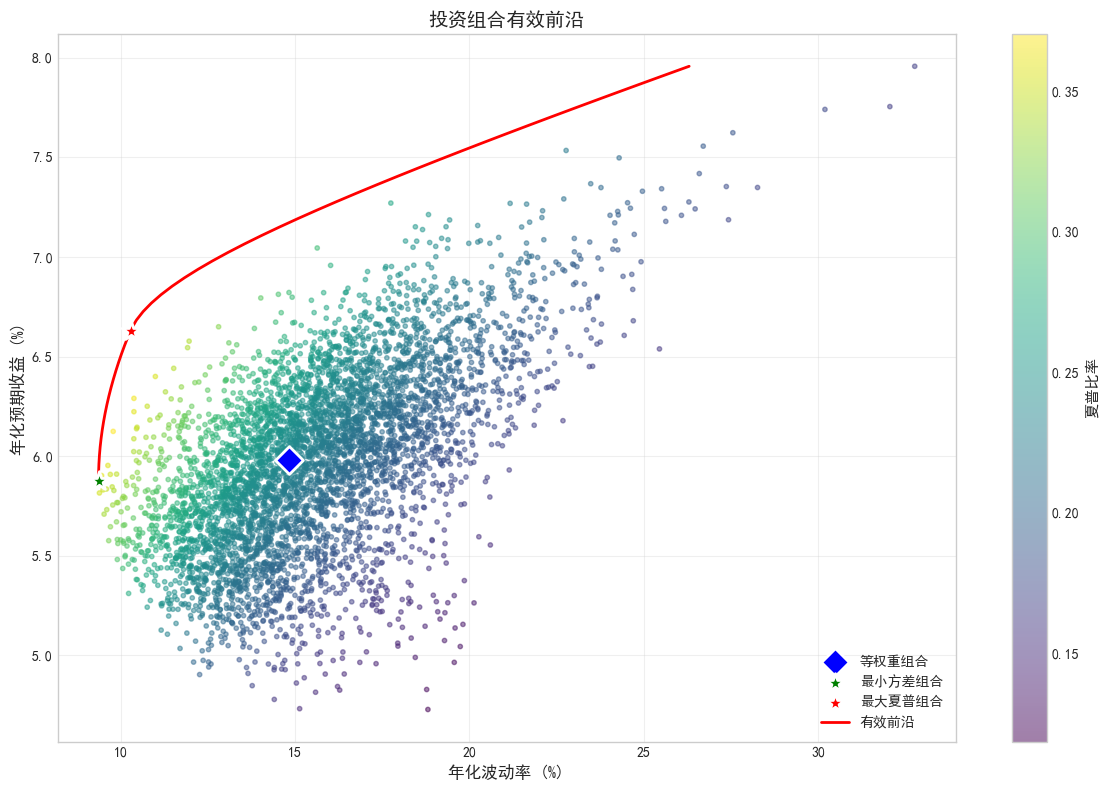

有效前沿图已保存至 output/Q7_efficient_frontier/efficient_frontier.png


In [49]:
# 绘制有效前沿
fig, ax = plt.subplots(figsize=(12, 8))

# 绘制蒙特卡洛模拟散点
scatter = ax.scatter(sim_volatilities*100, sim_returns*100,
                      c=sim_sharpes, cmap='viridis', alpha=0.5, s=10)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('夏普比率', fontsize=11)

# 等权重组合
eq_weights = np.ones(n_assets) / n_assets
eq_return = portfolio_return(eq_weights, mean_returns)
eq_vol = portfolio_volatility(eq_weights, cov_matrix)
eq_sharpe = (eq_return - RF_ANNUAL) / eq_vol
ax.scatter(eq_vol*100, eq_return*100, color='blue', s=200, marker='D',
           edgecolors='white', linewidth=2, zorder=5, label='等权重组合')

# 最小方差组合
ax.scatter(min_var_vol*100, min_var_return*100, color='green', s=200, marker='*',
           edgecolors='white', linewidth=2, zorder=5, label='最小方差组合')

# 最大夏普比率组合
ax.scatter(max_sharpe_vol*100, max_sharpe_return*100, color='red', s=200, marker='*',
           edgecolors='white', linewidth=2, zorder=5, label='最大夏普组合')

# 绘制有效前沿曲线
target_returns = np.linspace(min_var_return, np.max(sim_returns), 50)
efficient_vols = []

for target_ret in target_returns:
    constraints_ef = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, r=target_ret: portfolio_return(x, mean_returns) - r}
    ]
    result = minimize(
        lambda w: portfolio_volatility(w, cov_matrix),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_ef,
        options={'ftol': 1e-10}
    )
    if result.success:
        efficient_vols.append(portfolio_volatility(result.x, cov_matrix))
    else:
        efficient_vols.append(np.nan)

ax.plot(np.array(efficient_vols)*100, target_returns*100, 'r-', linewidth=2,
        label='有效前沿', zorder=4)

ax.set_xlabel('年化波动率 (%)', fontsize=12)
ax.set_ylabel('年化预期收益 (%)', fontsize=12)
ax.set_title('投资组合有效前沿', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q7, 'efficient_frontier.png'), dpi=150, bbox_inches='tight')
plt.show()

print('有效前沿图已保存至 output/Q7_efficient_frontier/efficient_frontier.png')

**结果解读**: 本代码绘制有效前沿曲线，标注三个特殊组合的位置。有效前沿是给定风险水平下收益最高（或给定收益下风险最低）的组合集合，红线为有效前沿边界。

In [50]:
# 保存有效前沿相关结果
efficient_frontier_results = {
    '组合类型': ['等权重组合', '最小方差组合', '最大夏普组合'],
    'ICBC': [eq_weights[0], min_var_weights[0], max_sharpe_weights[0]],
    'YILI': [eq_weights[1], min_var_weights[1], max_sharpe_weights[1]],
    'ZTE': [eq_weights[2], min_var_weights[2], max_sharpe_weights[2]],
    'YUNNAN': [eq_weights[3], min_var_weights[3], max_sharpe_weights[3]],
    'SINOPEC': [eq_weights[4], min_var_weights[4], max_sharpe_weights[4]],
    '年化收益': [eq_return, min_var_return, max_sharpe_return],
    '年化波动': [eq_vol, min_var_vol, max_sharpe_vol],
    '夏普比率': [eq_sharpe, min_var_sharpe, max_sharpe_ratio]
}

ef_df = pd.DataFrame(efficient_frontier_results)
ef_df.to_csv(os.path.join(OUTPUT_Q7, 'efficient_frontier_portfolios.csv'), index=False)

print('='*80)
print('有效前沿特殊组合对比')
print('='*80)
print(ef_df.round(4).to_string(index=False))

有效前沿特殊组合对比
  组合类型   ICBC   YILI    ZTE  YUNNAN  SINOPEC   年化收益   年化波动   夏普比率
 等权重组合 0.2000 0.2000 0.2000  0.2000   0.2000 0.0598 0.1484 0.2345
最小方差组合 0.6132 0.0389 0.0138  0.0537   0.2804 0.0588 0.0936 0.3605
最大夏普组合 0.9183 0.0000 0.0817  0.0000   0.0000 0.0663 0.1028 0.4017


**结果解读**: 本代码保存有效前沿特殊组合的配置和绩效数据，包括等权重组合、最小方差组合和最大夏普组合的权重分配、年化收益、波动率和夏普比率。

In [51]:
# 打印任务完成信息
print('='*80)
print('投资组合分析完成！')
print('='*80)
print('\n生成的数据文件:')
print('  1. correlation_matrix.csv - 相关系数矩阵')
print('  2. rolling_correlation.csv - 滚动相关系数')
print('  3. portfolio_performance.csv - 组合绩效指标')
print('  4. nav_data.csv - 净值数据')
print('  5. efficient_frontier_portfolios.csv - 有效前沿组合')
print('\n生成的图形文件:')
print('  1. correlation_heatmap.png - 相关系数热力图')
print('  2. rolling_correlation.png - 滚动相关系数时序图')
print('  3. portfolio_nav.png - 组合净值曲线')
print('  4. efficient_frontier.png - 有效前沿图')

投资组合分析完成！

生成的数据文件:
  1. correlation_matrix.csv - 相关系数矩阵
  2. rolling_correlation.csv - 滚动相关系数
  3. portfolio_performance.csv - 组合绩效指标
  4. nav_data.csv - 净值数据
  5. efficient_frontier_portfolios.csv - 有效前沿组合

生成的图形文件:
  1. correlation_heatmap.png - 相关系数热力图
  2. rolling_correlation.png - 滚动相关系数时序图
  3. portfolio_nav.png - 组合净值曲线
  4. efficient_frontier.png - 有效前沿图


**结果解读**: 本代码打印投资组合分析任务的完成信息，列出生成的数据文件和图形文件清单，包括相关系数矩阵、滚动相关系数、组合绩效、净值曲线和有效前沿分析结果。